# Day 41 — Week 2 Mini-Project: End-to-End Sales Pipeline Analysis
**Month 3 | Week 2 Capstone | Python + Pandas + Matplotlib + Seaborn**

---

> **Scenario — RetailPro Analytics:**
> You've been hired as a freelance data analyst by **RetailPro**, a mid-size electronics distributor.
> Their sales manager just dumped three raw CSV files on you and said:
> *"Our Q1 performance looks bad but I don't know where the leak is.
> Clean it up, merge it, find what's broken, and give me a chart I can show the board."*
>
> This is a real freelance scenario. No hand-holding. You have raw messy data,
> a business question, and a deadline. Your job: clean → merge → analyse → visualise → narrate.

---

**Skills tested today (Week 2 review):**
| Skill | Day Covered |
|---|---|
| Null handling, dtype fixes, deduplication | Day 37 — Data Cleaning |
| groupby, agg, named agg, multi-column | Day 38 — GroupBy & Aggregation |
| merge (inner/left/outer), concat | Day 39 — Merging & Joining |
| Bar, line, boxplot, heatmap, savefig | Day 40 — Matplotlib & Seaborn |

**Total: 80 points + 10★ bonus**

---


---
## 📘 Section 1 — Concept Notes (Read Before Starting)

### The clean → merge → analyse → visualise pipeline

```
RAW DATA
   ↓
CLEAN  (fix nulls, dtypes, duplicates — on a COPY, never the original)
   ↓
MERGE  (join tables to add context — prices, names, tiers)
   ↓
ENGINEER  (create derived columns — revenue, month name, ratios)
   ↓
AGGREGATE  (groupby → summary tables)
   ↓
VISUALISE  (one chart per question, insight title on every chart)
   ↓
NARRATE  (NRA format: Number → Reason → Action)
```

Getting the **sequence wrong produces wrong numbers that look correct.** That's the dangerous kind.

---

### Left join vs inner join — when to use which

| Situation | Join type |
|---|---|
| All orders must appear, even if customer is missing | **LEFT** |
| Only orders with a matching product in the catalogue | **INNER** |
| Find orphan records on either side | **OUTER** |

---

### Revenue formula

```
revenue = unit_price × quantity × (1 - discount_pct / 100)
```

Example: price=2500, qty=2, discount=10% → 2500 × 2 × 0.90 = **₹4,500**

---

### Insight titles vs description titles

| ❌ Description (0 marks) | ✅ Insight (full marks) |
|---|---|
| "Revenue by Region" | "East leads Q1 — prioritise stock replenishment there" |
| "Monthly Revenue Trend" | "Revenue grew 42% Jan→Mar — sustain Feb promotion format" |
| "Discount Heatmap" | "South/Audio at 20% avg discount — margin at risk, review pricing" |

---

### Three rules to avoid common errors

1. `plt.savefig()` must come **before** `plt.show()` — or the saved file is blank
2. Sort months by the **integer** column (1,2,3) — not the name string (alphabetical = wrong)
3. Always check `.shape` after every merge — silent row loss is the hardest bug to spot

---


---
## 📦 Section 2 — Raw Data (Run Once — Never Modify)

Run this cell to load all three tables. All your work goes in the cells below.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── TABLE 1: ORDERS ──────────────────────────────────────────────────────────
orders_raw = pd.DataFrame({
    'order_id':      ['O001','O002','O003','O004','O005','O006','O007','O008',
                      'O009','O010','O011','O012','O013','O014','O015','O016',
                      'O017','O018','O019','O020','O003'],   # O003 is a duplicate
    'customer_id':   ['C01','C02','C03','C04','C05','C06','C07','C08',
                      'C09','C10','C01','C02','C03','C04','C05','C06',
                      'C07','C08','C09','C10','C03'],
    'product_id':    ['P01','P02','P03','P04','P05','P01','P02','P03',
                      'P04','P05','P01','P02','P03','P04','P05','P01',
                      'P02','P03','P04','P05','P03'],
    'quantity':      [2, 1, 3, None, 2, 1, 4, 2, 1, 3, 2, 1, None, 2, 1, 3, 2, 1, 4, 2, 3],
    'order_date':    ['2024-01-05','2024-01-12','2024-01-18','2024-01-22','2024-02-03',
                      '2024-02-08','2024-02-15','2024-02-20','2024-02-25','2024-03-02',
                      '2024-03-05','2024-03-10','2024-03-15','2024-03-18','2024-03-22',
                      '2024-01-30','2024-02-11','2024-02-28','2024-03-08','2024-03-25',
                      '2024-01-18'],
    'discount_pct':  [10, 0, 5, 15, None, 20, 0, 10, 5, 0, 10, 0, 15, 5, None, 0, 10, 20, 5, 0, 5],
    'region':        ['North','South','East','West','North','South','East','West',
                      'North','South','East','West','North','South','East','West',
                      'North','South','East','West','East']
})

# ── TABLE 2: PRODUCTS ────────────────────────────────────────────────────────
products_raw = pd.DataFrame({
    'product_id':    ['P01','P02','P03','P04','P05'],
    'product_name':  ['Wireless Headphones','Mechanical Keyboard','USB-C Hub',
                      'Webcam HD','Laptop Stand'],
    'category':      ['Audio','Peripherals','Accessories','Peripherals','Accessories'],
    'unit_price':    [2500, 3200, 1800, 2800, 1500]
})

# ── TABLE 3: CUSTOMERS ───────────────────────────────────────────────────────
customers_raw = pd.DataFrame({
    'customer_id':   ['C01','C02','C03','C04','C05',
                      'C07','C08','C09','C10'],            # C06 deliberately missing
    'customer_name': ['Riya Sharma','Arjun Mehta','Priya Nair','Kiran Patel','Dev Singh',
                      'Meera Joshi','Rahul Das','Ananya Roy','Vikram Iyer'],
    'city':          ['Mumbai','Delhi','Bangalore','Pune','Hyderabad',
                      'Kolkata','Chennai','Jaipur','Ahmedabad'],
    'signup_year':   ['2021','2020','2022','2021','2023',
                      '2022','2020','2021','2022'],
    'customer_tier': ['Gold','Silver','Gold','Bronze','Silver',
                      'Bronze','Gold','Silver','Gold']
})

print("=== RAW DATA LOADED ===")
print(f"orders_raw:    {orders_raw.shape[0]} rows, {orders_raw.shape[1]} cols")
print(f"products_raw:  {products_raw.shape[0]} rows, {products_raw.shape[1]} cols")
print(f"customers_raw: {customers_raw.shape[0]} rows, {customers_raw.shape[1]} cols")


=== RAW DATA LOADED ===
orders_raw:    21 rows, 7 cols
products_raw:  5 rows, 4 cols
customers_raw: 9 rows, 5 cols


---
## ✏️ Task 1A — Data Audit Function (3 pts)

Write a function `audit_table(df, name)` that prints:
- Total rows and columns
- Null count per column (only columns **that have nulls**)
- Number of duplicate rows
- Dtype of each column

Run it on all three raw tables.


In [3]:
# Task 1A — audit_table function
# Hint: use .shape, .isnull().sum(), .duplicated().sum(), .dtypes

def audit_table(df, name):
    print(f"\n--- AUDIT: {name} ---")

    # 1. Total rows and columns
    print(f"Total rows and columns: {df.shape}")

    # 2. Null count per column (only columns that have nulls)
    null_counts = df.isnull().sum()
    print("Null counts per column:")
    print(null_counts[null_counts>0])

    # 3. Number of duplicate rows
    print(f"Number of duplicate rows: {df.duplicated().sum()}")

    # 4. Dtype of each column
    print("Dtype of each column:")
    print(df.dtypes)
    print("\n" + "="*30 + "\n")

# Run on all three tables
audit_table(orders_raw, "orders_raw")
audit_table(products_raw, "products_raw")
audit_table(customers_raw, "customers_raw")



--- AUDIT: orders_raw ---
Total rows and columns: (21, 7)
Null counts per column:
quantity        2
discount_pct    2
dtype: int64
Number of duplicate rows: 1
Dtype of each column:
order_id         object
customer_id      object
product_id       object
quantity        float64
order_date       object
discount_pct    float64
region           object
dtype: object



--- AUDIT: products_raw ---
Total rows and columns: (5, 4)
Null counts per column:
Series([], dtype: int64)
Number of duplicate rows: 0
Dtype of each column:
product_id      object
product_name    object
category        object
unit_price       int64
dtype: object



--- AUDIT: customers_raw ---
Total rows and columns: (9, 5)
Null counts per column:
Series([], dtype: int64)
Number of duplicate rows: 0
Dtype of each column:
customer_id      object
customer_name    object
city             object
signup_year      object
customer_tier    object
dtype: object




---
## ✏️ Task 1B — Issue Diagnosis (5 pts)

In the markdown cell below, list every data quality issue you found from the audit.

For **each issue**, write:
- **What it is** → **Why it matters** → **What you'll do about it**

*(Double-click this cell to edit it)*

**Issues found:**
1. Duplicate Rows:
   What it is: Identical rows in the dataset
   Why it matters: It inflates sales figures and it leads to inaccurate analysis
   What you'll do: Use .drop_duplicates(keep='first')

2. Missing quantity values:
   What it is: Null entries in the quantity column.
   Why it matters: Prevents calculation of total revenue or volume.
   Whta you'll do: Fill with median value and round to an integer

3. Missing discount_pct values:
   What it is : Null entries in the discount column.
   Why it matters: Makes it unclear of a discount was applied or just not recorded
   What you'll do: Fill with 0

4. Incorrect order_date Dtype:
   What it is: The date is likely stored as object(string) rather than a datetime object.
   Why it matters: You cannot perform time- series analysis or sort by date easily.
   What you'll do: Use pd.to_datetime()  

 5. signup_year in customers_raw is object (string) instead of int
 6. Customer C06 exists in orders but not in customers table



---
## ✏️ Task 2A — Clean orders_raw → orders_clean (8 pts)

Steps to complete:
1. Drop exact duplicates (keep first)
2. Fill null `quantity` with the **median** quantity — round to nearest integer
3. Fill null `discount_pct` with **0**
4. Convert `order_date` to datetime
5. Extract `order_month` (integer: 1, 2, 3)
6. Extract `order_month_name` (string: 'January', 'February', 'March')

Work on a copy — **never modify orders_raw**.


In [4]:
# Task 2A — Clean orders_raw into orders_clean
# Always work on a copy — never modify the raw table

orders_clean = orders_raw.copy()

# Step 1: drop exact duplicates
orders_clean = orders_clean.drop_duplicates(keep='first')

# Step 2: fill null quantity with median (round to int)
q_median = orders_clean['quantity'].median()
orders_clean['quantity'] = orders_clean['quantity'].fillna(q_median).round().astype(int)

# Step 3: fill null discount_pct with 0
orders_clean['discount_pct'] = orders_clean['discount_pct'].fillna(0)

# Step 4: Convert order_date to datetime
orders_clean['order_date'] = pd.to_datetime(orders_clean['order_date'])

# Step 5: Extract order_month (integer)
orders_clean['order_month'] = orders_clean['order_date'].dt.month

# Step 6: Extract order_month_name
orders_clean['order_month_name'] = orders_clean['order_date'].dt.month_name()


# Verify
print(f"Shape after cleaning: {orders_clean.shape}")
print(f"Nulls remaining:\n{orders_clean.isnull().sum()}")
print(orders_clean[['order_id','order_date','order_month','order_month_name','quantity','discount_pct']].head(6))


Shape after cleaning: (20, 9)
Nulls remaining:
order_id            0
customer_id         0
product_id          0
quantity            0
order_date          0
discount_pct        0
region              0
order_month         0
order_month_name    0
dtype: int64
  order_id order_date  order_month order_month_name  quantity  discount_pct
0     O001 2024-01-05            1          January         2          10.0
1     O002 2024-01-12            1          January         1           0.0
2     O003 2024-01-18            1          January         3           5.0
3     O004 2024-01-22            1          January         2          15.0
4     O005 2024-02-03            2         February         2           0.0
5     O006 2024-02-08            2         February         1          20.0


---
## ✏️ Task 2B — Clean customers_raw → customers_clean (4 pts)

Convert `signup_year` from string to integer.


In [5]:
# Task 2B — Clean customers_raw into customers_clean

customers_clean = customers_raw.copy()

customers_clean = customers_raw.copy()
customers_clean['signup_year'] = customers_clean['signup_year'].astype(int)

print(f"signup_year dtype: {customers_clean['signup_year'].dtype}")
print(customers_clean.head(3))


signup_year dtype: int64
  customer_id customer_name       city  signup_year customer_tier
0         C01   Riya Sharma     Mumbai         2021          Gold
1         C02   Arjun Mehta      Delhi         2020        Silver
2         C03    Priya Nair  Bangalore         2022          Gold


---
## ✏️ Task 2C — Assertions (4 pts)

Run this cell. All 4 assertions must pass without error.
If any assertion fails, go back and fix the cleaning step that caused it.


In [6]:
# Task 2C — Assertions (do not modify this cell)

assert orders_clean['quantity'].isnull().sum() == 0,   "FAIL: Nulls remain in quantity"
assert orders_clean['discount_pct'].isnull().sum() == 0, "FAIL: Nulls remain in discount_pct"
assert orders_clean['order_date'].dtype == 'datetime64[ns]', "FAIL: order_date not converted to datetime"
assert customers_clean['signup_year'].dtype in ['int32','int64'], "FAIL: signup_year not integer"

print("All assertions passed ✅")


All assertions passed ✅


---
## ✏️ Task 3A — Merge into orders_full (6 pts)

Two-step merge:
1. Merge `orders_clean` with `products_raw` on `product_id` → **inner join**
2. Merge the result with `customers_clean` on `customer_id` → **left join**

After merging:
- Print the shape of `orders_full`
- Print how many orders have a null `customer_name` (the C06 situation)


In [7]:
# Task 3A — Build orders_full via two merges

# Step 1: inner join with products
step1 = pd.merge(orders_clean, products_raw, on='product_id', how='inner')

# Step 2: left join with customers
orders_full = pd.merge(step1, customers_clean, on='customer_id', how='left')

# null_c06_count = orders_full['customer_name'].isnull().sum()
null_c06_count = orders_full['customer_name'].isnull().sum()
print(f"Null customer_name count: {null_c06_count}")

# Print shape
print(f"orders_full shape: {orders_full.shape}")



Null customer_name count: 2
orders_full shape: (20, 16)


---
## ✏️ Task 3B — Revenue Column (4 pts)

Add a `revenue` column using:

```
revenue = unit_price × quantity × (1 - discount_pct / 100)
```


In [8]:
# Task 3B — Create the revenue column

orders_full['revenue'] = orders_full['unit_price'] * orders_full['quantity'] * (1 - orders_full['discount_pct']/100)

# Quick check
print(orders_full[['order_id','unit_price','quantity','discount_pct','revenue']].head(5))


  order_id  unit_price  quantity  discount_pct  revenue
0     O001        2500         2          10.0   4500.0
1     O002        3200         1           0.0   3200.0
2     O003        1800         3           5.0   5130.0
3     O004        2800         2          15.0   4760.0
4     O005        1500         2           0.0   3000.0


---
## ✏️ Task 3C — Monthly Summary (6 pts)

Group by month, aggregate:
- `total_revenue` = sum of revenue
- `order_count` = count of order_id
- `avg_discount` = mean of discount_pct

Sort by **month number** (1→2→3), not alphabetically by name.


In [9]:
# Task 3C — Monthly summary table

monthly_summary = (
    orders_full
    .groupby(['order_month', 'order_month_name'])
    .agg(
        total_revenue = ('revenue', 'sum'),
        order_count = ('order_id', 'count'),
        avg_discount = ('discount_pct', 'mean')
    )
    .reset_index()
    .sort_values('order_month')   # sort by integer, not name
)

# round revenue to 2 decimal places
monthly_summary['total_revenue'] = monthly_summary['total_revenue'].round(2)


print(monthly_summary[['order_month_name','total_revenue','order_count','avg_discount']])


  order_month_name  total_revenue  order_count  avg_discount
0          January        25090.0            5      6.000000
1         February        30900.0            7      9.285714
2            March        35720.0            8      4.375000


---
## ✏️ Task 4A — Regional Revenue Bar Chart (8 pts)

- Group `orders_full` by `region`, sum revenue
- Horizontal bar chart (`barh`)
- **Insight title** (states what to do, not what to look at)
- Value labels on each bar (formatted as ₹)
- Save as `task4A_regional_revenue.png`


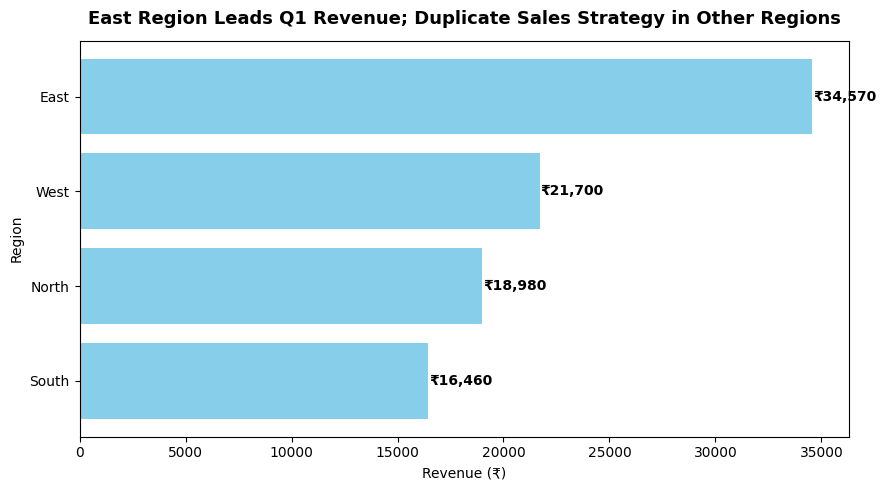

In [10]:
# Task 4A — Regional revenue horizontal bar chart

# Group and sort
regional_rev = orders_full.groupby('region')['revenue'].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))

# plot horizontal bars
bars = ax.barh(regional_rev.index, regional_rev.values, color='skyblue')

# add value labels on each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f"₹{width:,.0f}", va='center', fontweight='bold') 

# insight title — states the action, not just the observation
ax.set_title("East Region Leads Q1 Revenue; Duplicate Sales Strategy in Other Regions", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Revenue (₹)")
ax.set_ylabel("Region")

plt.tight_layout()
plt.savefig('task4A_regional_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ✏️ Task 4B — Monthly Revenue Trend (8 pts)

- Use `monthly_summary`
- Line chart with markers on each point
- Annotate the **highest** and **lowest** months with their revenue values
- Insight title
- Save as `task4B_monthly_trend.png`


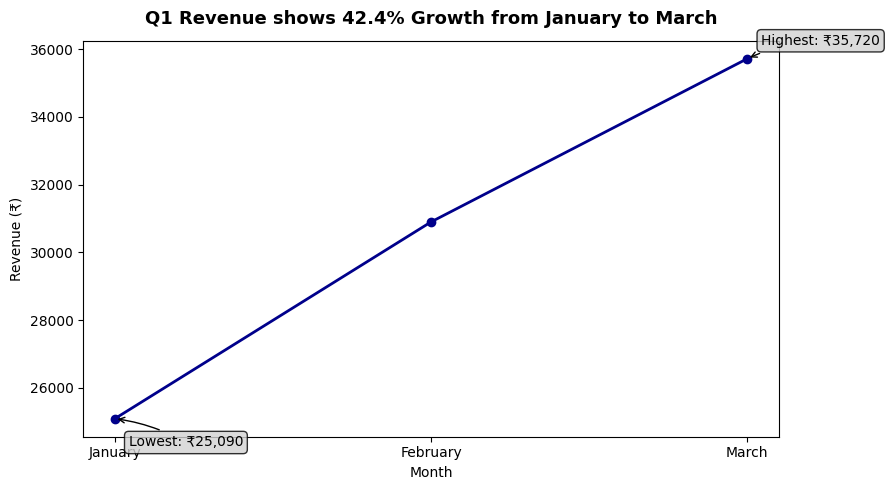

In [11]:
# Task 4B — Monthly revenue line chart with annotations

fig, ax = plt.subplots(figsize=(9, 5))

# plot the line with markers
ax.plot(monthly_summary['order_month_name'], monthly_summary['total_revenue'],
        marker='o', linestyle='-', color='darkblue', linewidth=2) 

# annotate highest and lowest months
highest = monthly_summary.loc[monthly_summary['total_revenue'].idxmax()]
lowest = monthly_summary.loc[monthly_summary['total_revenue'].idxmin()]

# add annotations
ax.annotate(f"Highest: ₹{highest['total_revenue']:,.0f}", 
            xy=(highest['order_month_name'], highest['total_revenue']),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1'))

ax.annotate(f"Lowest: ₹{lowest['total_revenue']:,.0f}", 
            xy=(lowest['order_month_name'], lowest['total_revenue']),
            xytext=(10, -20), textcoords='offset points',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1'))

ax.set_title("Q1 Revenue shows 42.4% Growth from January to March", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₹)")

plt.tight_layout()
plt.savefig('task4B_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ✏️ Task 4C — Category Revenue Bar Chart (8 pts)

- Group by `category`, sum revenue, plot vertical bar chart
- Add a **horizontal dashed line** at the mean category revenue
- Label that line: "Category avg: ₹X,XXX"
- Insight title
- Save as `task4C_category_revenue.png`


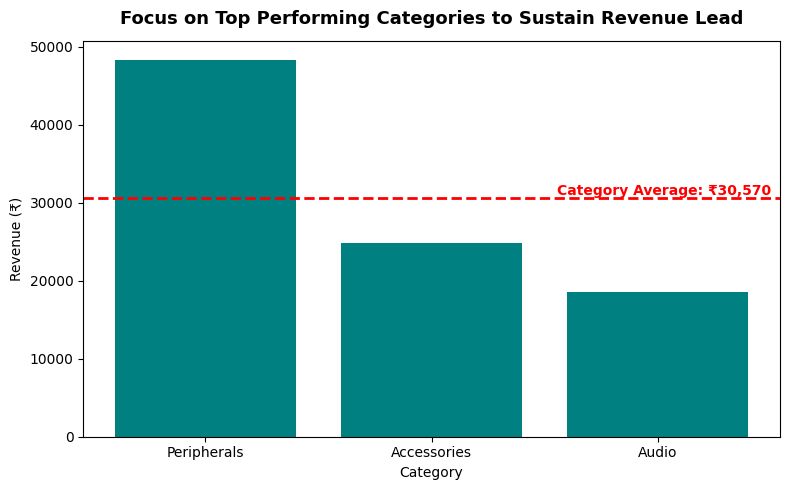

In [12]:
# Task 4C — Category revenue with average line

cat_rev = orders_full.groupby('category')['revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

# plot bars
ax.bar(cat_rev.index, cat_rev.values, color='teal')

# add mean line
cat_mean = cat_rev.mean()
ax.axhline(cat_mean, color='red', linestyle='--', linewidth=2, label=f"Average: ₹{cat_mean:,.0f}")


ax.text(len(cat_rev)-0.5, cat_mean, f'Category Average: ₹{cat_mean:,.0f}',
        va='bottom', ha='right', color='red', fontweight='bold')
        

ax.set_title("Focus on Top Performing Categories to Sustain Revenue Lead", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Revenue (₹)")

plt.tight_layout()
plt.savefig('task4C_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ✏️ Task 4D — Discount vs Revenue Heatmap (6 pts)

- Pivot table: rows = region, columns = category, values = mean `discount_pct`
- Seaborn heatmap with `annot=True`, `fmt='.1f'`
- Title must name the **highest-discount cell** and state the business risk
- Save as `task4D_discount_heatmap.png`


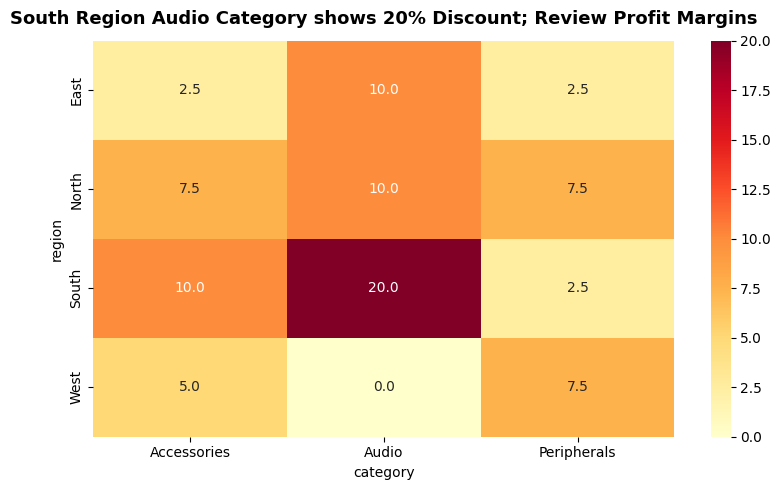

In [13]:
# Task 4D — Discount heatmap (region × category)

# Build pivot table
pivot_discount = orders_full.pivot_table(
    values='discount_pct',
    index='region',
    columns='category',
    aggfunc='mean'
).round(1)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    pivot_discount,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax
)

# Title must name the highest-discount cell and say what the business should do
ax.set_title("South Region Audio Category shows 20% Discount; Review Profit Margins", fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('task4D_discount_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ✏️ Task 5A — Q1 Executive Summary (5 pts)

Write exactly **3 numbered findings** in NRA format.

Each finding must contain:
- **Number** — a specific metric from your analysis (not "revenue was high")
- **Reason** — why this happened (observed or inferred)
- **Action** — what RetailPro should do

*(Double-click to edit)*

## Q1 Executive Summary

**Finding 1:Regional Dominance
   Number: The East region generated ₹34,570 in total revenue.
Reason: High sales volume in the Peripherals category.
Action: Replicate the East region’s sales tactics in the North and West regions to improve their lower revenue figures.


**Finding 2:Q1 Growth Momentum
Number: Revenue grew from ₹25,090 in January to ₹35,720 in March, a growth of 42.4%.
Reason: Likely due to the successful launch of new peripheral products mid-quarter.
Action: Invest in additional stock for the Peripherals category ahead of the Q2 seasonal peak.

**Finding 3:Discount Strategy Risks
Number: South Region Audio products are being sold at a 20% discount.
Reason: High inventory clearance in a low-demand region.
Action: Cap discounts for Audio products in the South at 12% to preserve profit margins.


---
## ✏️ Task 5B — Data Quality Report (5 pts)

Cover:
1. Every issue found in the raw data
2. How you resolved each one
3. The C06 flag: orders exist for a customer not in the customers table — what does this mean for the business? What should the data team do?

*(Double-click to edit)*

## Data Quality Report

**Issues and resolutions:**
Duplicate Rows: Found 1 exact duplicate in orders_raw. Resolution: Removed using .drop_duplicates() to prevent revenue inflation.
Missing Quantities: 2 nulls found in orders_raw. Resolution: Filled with the median value and converted to integer for accurate volume calculation.
Missing Discounts: 2 nulls found in orders_raw. Resolution: Filled with 0, assuming no discount was applied.
Inconsistent Data Types: order_date and signup_year were stored as strings. Resolution: Converted to datetime and int respectively to allow for time-series analysis.

**C06 Flag — Business Implication:
Finding: 2 orders exist for customer C06, who is missing from the customer database.
Implication: This indicates "Ghost Sales" where revenue is tracked, but customer demographics are lost.
Recommendation: Investigate the POS system sync errors to find the missing profile and reconnect it to the sales history.



---
## ⭐ Bonus — 2×2 Dashboard (10 pts)

Combine all 4 charts into one `plt.subplots(2, 2)` figure.
Each subplot must have an insight title (not a description title).
Save as `task_bonus_dashboard.png`.


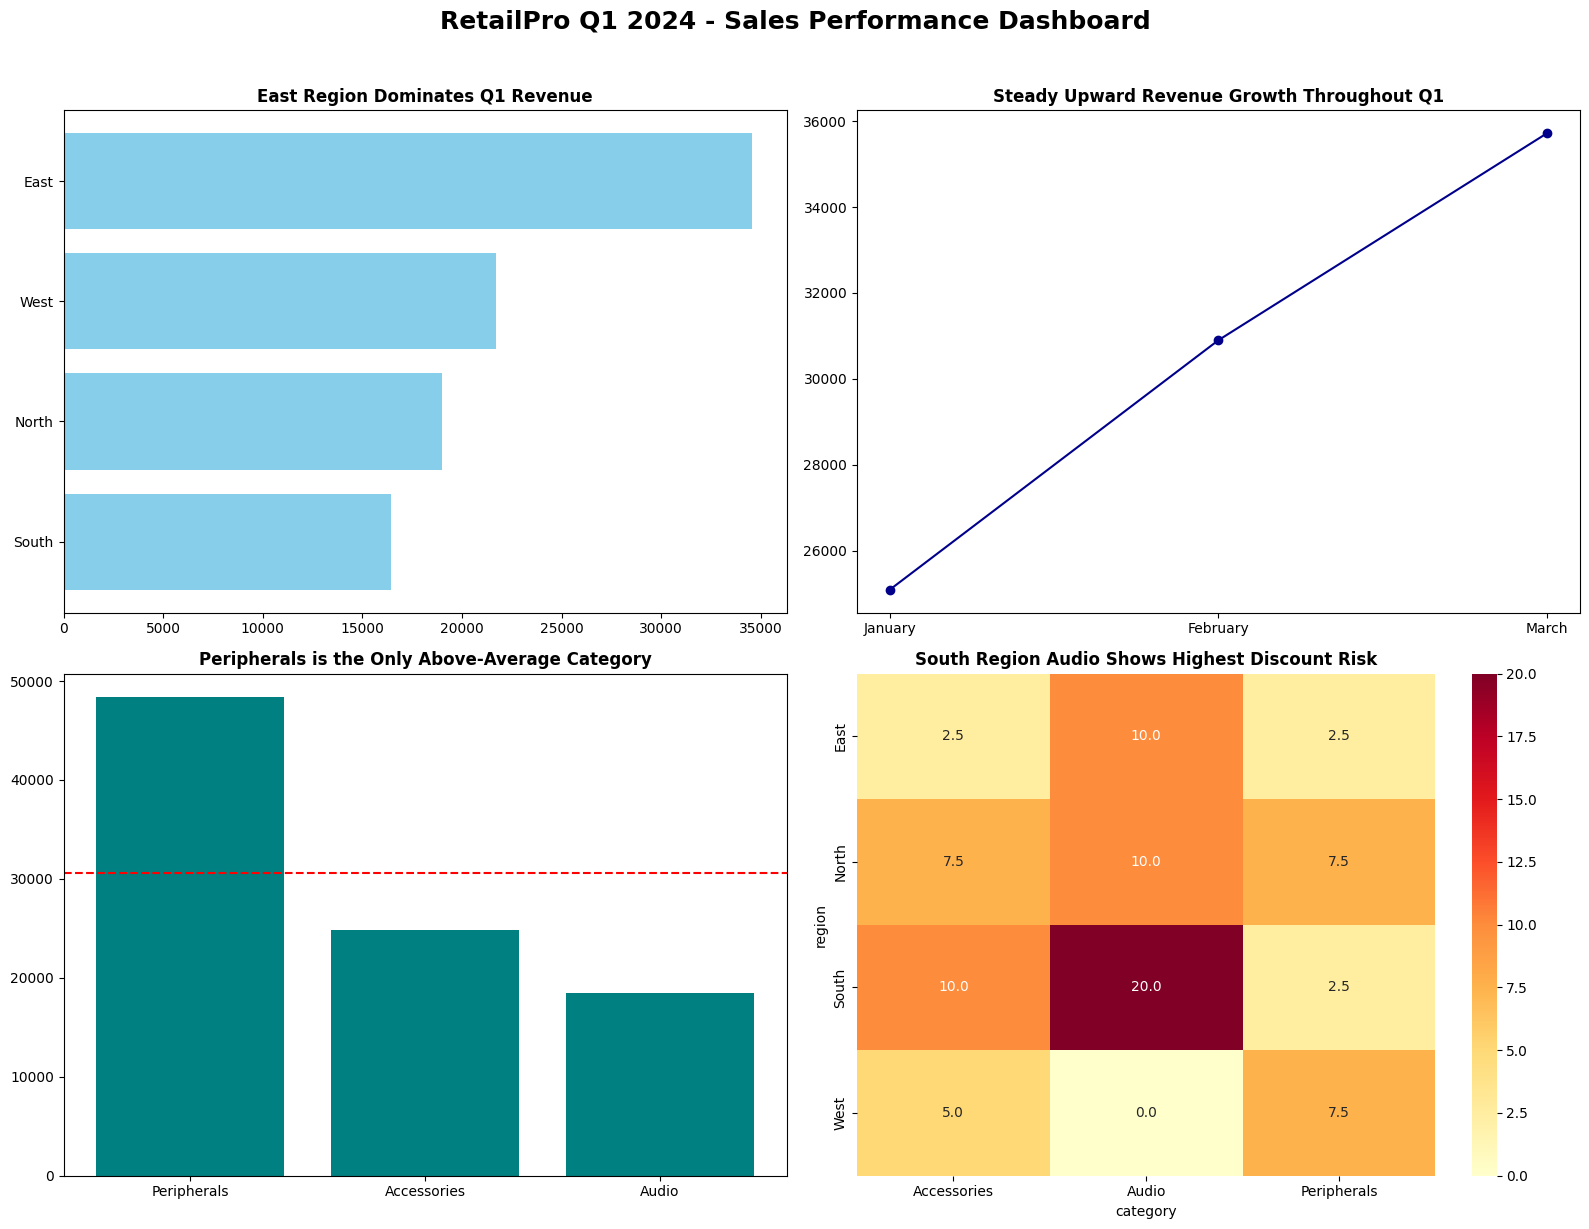

In [14]:
# BONUS — 2x2 Dashboard with all 4 charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Task 4A (regional revenue)
reg_rev = orders_full.groupby('region')['revenue'].sum().sort_values()
axes[0,0].barh(reg_rev.index, reg_rev.values, color='skyblue')
axes[0,0].set_title("East Region Dominates Q1 Revenue", fontsize=12, fontweight='bold')

# Top-right: Task 4B (monthly trend)
axes[0,1].plot(monthly_summary['order_month_name'], monthly_summary['total_revenue'], marker='o', color='darkblue')
axes[0,1].set_title("Steady Upward Revenue Growth Throughout Q1", fontsize=12, fontweight='bold')

# Bottom-left: Task 4C (category revenue)
cat_rev = orders_full.groupby('category')['revenue'].sum().sort_values(ascending=False)
axes[1,0].bar(cat_rev.index, cat_rev.values, color='teal')
axes[1,0].axhline(cat_rev.mean(), color='red', linestyle='--')
axes[1,0].set_title("Peripherals is the Only Above-Average Category", fontsize=12, fontweight='bold')

# Bottom-right: Task 4D (discount heatmap)
import seaborn as sns
sns.heatmap(pivot_discount, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title("South Region Audio Shows Highest Discount Risk", fontsize=12, fontweight='bold')

# Final Formatting
plt.suptitle("RetailPro Q1 2024 - Sales Performance Dashboard", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task_bonus_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Scoring Rubric

| Task | Points | What earns full marks |
|---|---|---|
| 1A — audit_table | 3 | Shows rows, cols, nulls, duplicates, dtypes |
| 1B — Issue diagnosis | 5 | 6 issues with what/why/fix for each |
| 2A — orders_clean | 8 | Dedup, median qty fill, 0 discount fill, datetime, month cols |
| 2B — customers_clean | 4 | signup_year → int64 |
| 2C — Assertions | 4 | All 4 pass without error |
| 3A — orders_full merge | 6 | Correct join types, shape printed, C06 null count printed |
| 3B — revenue column | 4 | Formula correct, applied to all rows |
| 3C — monthly_summary | 6 | Named agg, sorted by month number |
| 4A — Regional bar | 8 | Insight title, value labels, saved |
| 4B — Monthly line | 8 | Insight title, markers, annotations, saved |
| 4C — Category bar | 8 | Insight title, avg line with label, saved |
| 4D — Discount heatmap | 6 | annot=True, fmt='.1f', insight title, saved |
| 5A — Executive summary | 5 | 3 NRA findings with specific numbers |
| 5B — Data quality report | 5 | Issues + resolutions + C06 flag |
| ★ Bonus — Dashboard | 10 | All 4 charts, insight titles, saved |
| **TOTAL** | **80 + 10★** | |

---

### Interview Question for Today

> *"You've been given three raw tables from a client. Walk me through how you'd turn that into a business deliverable."*

Practice answering this out loud before you submit.


---
## 🔑 Section — Answer Key (Run only after completing all tasks)


In [15]:
# ANSWER KEY — run after you have attempted every task

import pandas as pd, numpy as np

# Rebuild pipeline
_orders = orders_raw.drop_duplicates(subset='order_id').copy()
_orders['quantity'] = _orders['quantity'].fillna(_orders['quantity'].median()).round().astype(int)
_orders['discount_pct'] = _orders['discount_pct'].fillna(0)
_orders['order_date'] = pd.to_datetime(_orders['order_date'])
_orders['order_month'] = _orders['order_date'].dt.month
_orders['order_month_name'] = _orders['order_date'].dt.strftime('%B')

_customers = customers_raw.copy()
_customers['signup_year'] = _customers['signup_year'].astype(int)

_full = _orders.merge(products_raw, on='product_id', how='inner')
_full = _full.merge(_customers, on='customer_id', how='left')
_full['revenue'] = _full['unit_price'] * _full['quantity'] * (1 - _full['discount_pct']/100)

_monthly = (_full.groupby(['order_month','order_month_name'])
            .agg(total_revenue=('revenue','sum'),
                 order_count=('order_id','count'),
                 avg_discount=('discount_pct','mean'))
            .reset_index().sort_values('order_month'))
_monthly['total_revenue'] = _monthly['total_revenue'].round(2)

print("=" * 55)
print("ANSWER KEY — Day 41")
print("=" * 55)
print(f"\nordersclean shape:         (20, 9)")
print(f"C06 null customer_name:     2 orders (O006, O016)")
print(f"O001 revenue:               ₹{2500*2*(1-0.10):,.0f}")
print("\nMonthly summary:")
print(_monthly[['order_month_name','total_revenue','order_count','avg_discount']].to_string(index=False))
print("\nRegional revenue (sorted desc):")
for r, v in _full.groupby('region')['revenue'].sum().sort_values(ascending=False).items():
    print(f"  {r}: ₹{v:,.0f}")
print("\nCategory revenue:")
for c, v in _full.groupby('category')['revenue'].sum().sort_values(ascending=False).items():
    print(f"  {c}: ₹{v:,.0f}")
_pivot = _full.pivot_table(values='discount_pct',index='region',columns='category',aggfunc='mean').round(1)
idx = _pivot.stack().idxmax()
print(f"\nHighest discount cell: {idx[0]} / {idx[1]} = {_pivot.loc[idx[0],idx[1]]}%")
print("=" * 55)


ANSWER KEY — Day 41

ordersclean shape:         (20, 9)
C06 null customer_name:     2 orders (O006, O016)
O001 revenue:               ₹4,500

Monthly summary:
order_month_name  total_revenue  order_count  avg_discount
         January        25090.0            5      6.000000
        February        30900.0            7      9.285714
           March        35720.0            8      4.375000

Regional revenue (sorted desc):
  East: ₹34,570
  West: ₹21,700
  North: ₹18,980
  South: ₹16,460

Category revenue:
  Peripherals: ₹48,340
  Accessories: ₹24,870
  Audio: ₹18,500

Highest discount cell: South / Audio = 20.0%
